In [ ]:
import numpy as np
import pennylane as qml
import torch
from torch import nn
import matplotlib.pyplot as plt

In [22]:
import warnings
warnings.filterwarnings("ignore", category= UserWarning)

In [5]:
torch.manual_seed(42)
device = "mps"

In [6]:
n_qubits = 6
N = 2 ** n_qubits
mu, sigma = 0, 0.3

In [7]:
x_min,x_max = mu - 4*sigma, mu + 4*sigma
step_size =(x_max - x_min) / N

bin_edges = torch.linspace(x_min, x_max, N+1)
bin_centers = x_min + step_size/2 + torch.arange(N)*step_size

cdf_up_to_bin_edge = torch.distributions.Normal(mu, sigma).cdf(bin_edges)
cdf_per_bin = torch.diff(cdf_up_to_bin_edge)
probability_distribution = cdf_per_bin / torch.sum(cdf_per_bin)

In [ ]:
def bitstrings_to_indices(bit_samples):
    n = bit_samples.shape[1]
    powers = (2 ** torch.arange(n-1, -1, -1, device=bit_samples.device)).long()
    return torch.sum(bit_samples.long() * powers, dim=1)  

def indice_to_real_value(indice):
    return x_min + (indice + 0.5) * step_size

def sample_from_distribution(distribution, n_samples):
    sampled_indices = torch.multinomial(distribution, num_samples=n_samples, replacement=True)
    return sampled_indices

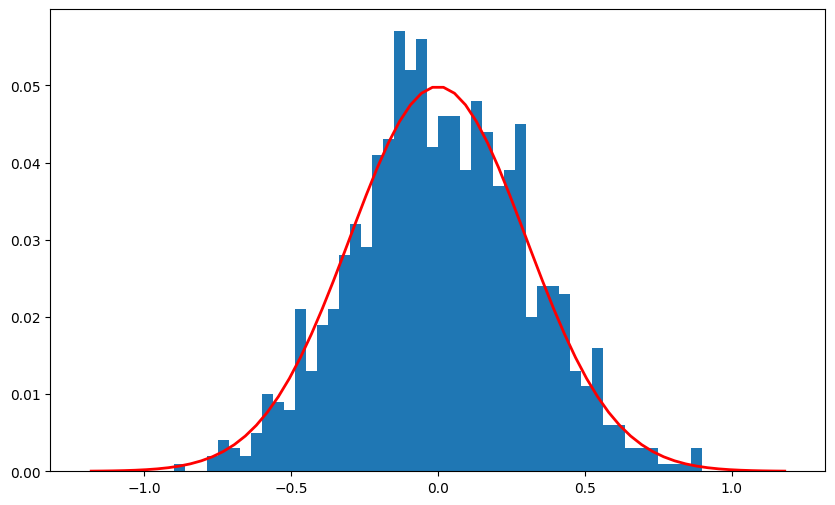

In [27]:
n_samples = 1000
X = sample_from_distribution(probability_distribution, int(n_samples))
bin_counts = np.bincount(X, minlength=N) / n_samples
plt.figure(figsize=(10,6))
plt.bar(bin_centers, bin_counts, width=step_size)
plt.plot(bin_centers, probability_distribution, color='red', linewidth=2)
plt.show()

# Network

In [ ]:
class QCBM_sampler(nn.Module):
    def __init__(self, n_qubits, n_layers, n_shots = None):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.n_shots = n_shots

        wires = range(n_qubits)[::-1]
        self.dev = qml.device("default.qubit", wires = wires)

        random_init = 0.1* torch.randn(n_layers, n_qubits, 3)
        self.weights = nn.Parameter(random_init)

        @qml.qnode(self.dev, interface="torch", diff_method="parameter-shift")
        def prob_net(weights):
            qml.StronglyEntanglingLayers(weights, wires=wires)
            return qml.probs(wires=wires)

        self.prob_net = qml.set_shots(prob_net, shots=self.n_shots)
    
    def forward(self):
        return self.prob_net(self.weights)

# Loss

In [12]:
def rbf_mixture_kernel_matrix_from_centers(centers,  sigmas):
    centers = centers.view(-1, 1)                
    dist2 = (centers - centers.T) ** 2            

    sig2 = (sigmas ** 2).view(-1, 1, 1)         
    K = torch.exp(-dist2.unsqueeze(0) / (2.0 * sig2)).mean(dim=0) 
    return K

K = rbf_mixture_kernel_matrix_from_centers(bin_centers, torch.tensor([0.1, 0.2, 0.3])).to(device)

def mmd2_probs(p, q, K):
    return torch.matmul(p, torch.matmul(K, p)) + torch.matmul(q, torch.matmul(K, q)) - 2 * torch.matmul(p, torch.matmul(K, q))

In [ ]:
def RBF_kernel(p, q, sigma):
    p = p[None,:]
    q = q[:,None]
    return torch.exp(-((p - q)**2) / (2 * sigma**2))

def mixed_RBF_kernels(p, q, sigmas):
    K = 0
    for sigma in sigmas:
        K += RBF_kernel(p, q, sigma)
    return K / len(sigmas)

def MMD_samples(target_samples, model_samples, sigmas):
    XX = mixed_RBF_kernels(model_samples, model_samples, sigmas)
    YY = mixed_RBF_kernels(target_samples, target_samples, sigmas)
    XY = mixed_RBF_kernels(model_samples, target_samples, sigmas)
    
    mmd = XX.mean() + YY.mean() - 2 * XY.mean()
    return mmd

# Training

In [13]:
def train_iteration(network, target_probs, K, opt):
    opt.zero_grad(set_to_none=True)

    q_probs = network.prob_net(network.weights).to(torch.float32)
    q_probs = q_probs.to(device)
    target_probs = target_probs.to(device)

    loss = mmd2_probs(target_probs, q_probs, K)

    loss.backward()
    opt.step()
    return loss.item(), q_probs.detach()

In [14]:
guassian_qcbm = QCBM_sampler(n_qubits=n_qubits, n_layers=3, n_shots=None)


In [ ]:
opt = torch.optim.Adam(guassian_qcbm.parameters(), lr=0.001)

loss_history = []
n_epochs = 1001

for epoch in range(n_epochs):
    loss, model_samples = train_iteration(guassian_qcbm, probability_distribution.to(device), K, opt)
    loss_history.append(loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: MMD Loss = {loss}")
        with torch.no_grad():
            q = guassian_qcbm.prob_net(guassian_qcbm.weights)
            print("Entropy:", -(q * torch.log(q + 1e-12)).sum().item())

In [ ]:

loss_history = []
n_epochs = 1001

for epoch in range(n_epochs):
    loss, model_samples = train_iteration(guassian_qcbm, probability_distribution.to(device), K, opt)
    loss_history.append(loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: MMD Loss = {loss}")
        with torch.no_grad():
            q = guassian_qcbm.prob_net(guassian_qcbm.weights)
            print("Entropy:", -(q * torch.log(q + 1e-12)).sum().item())

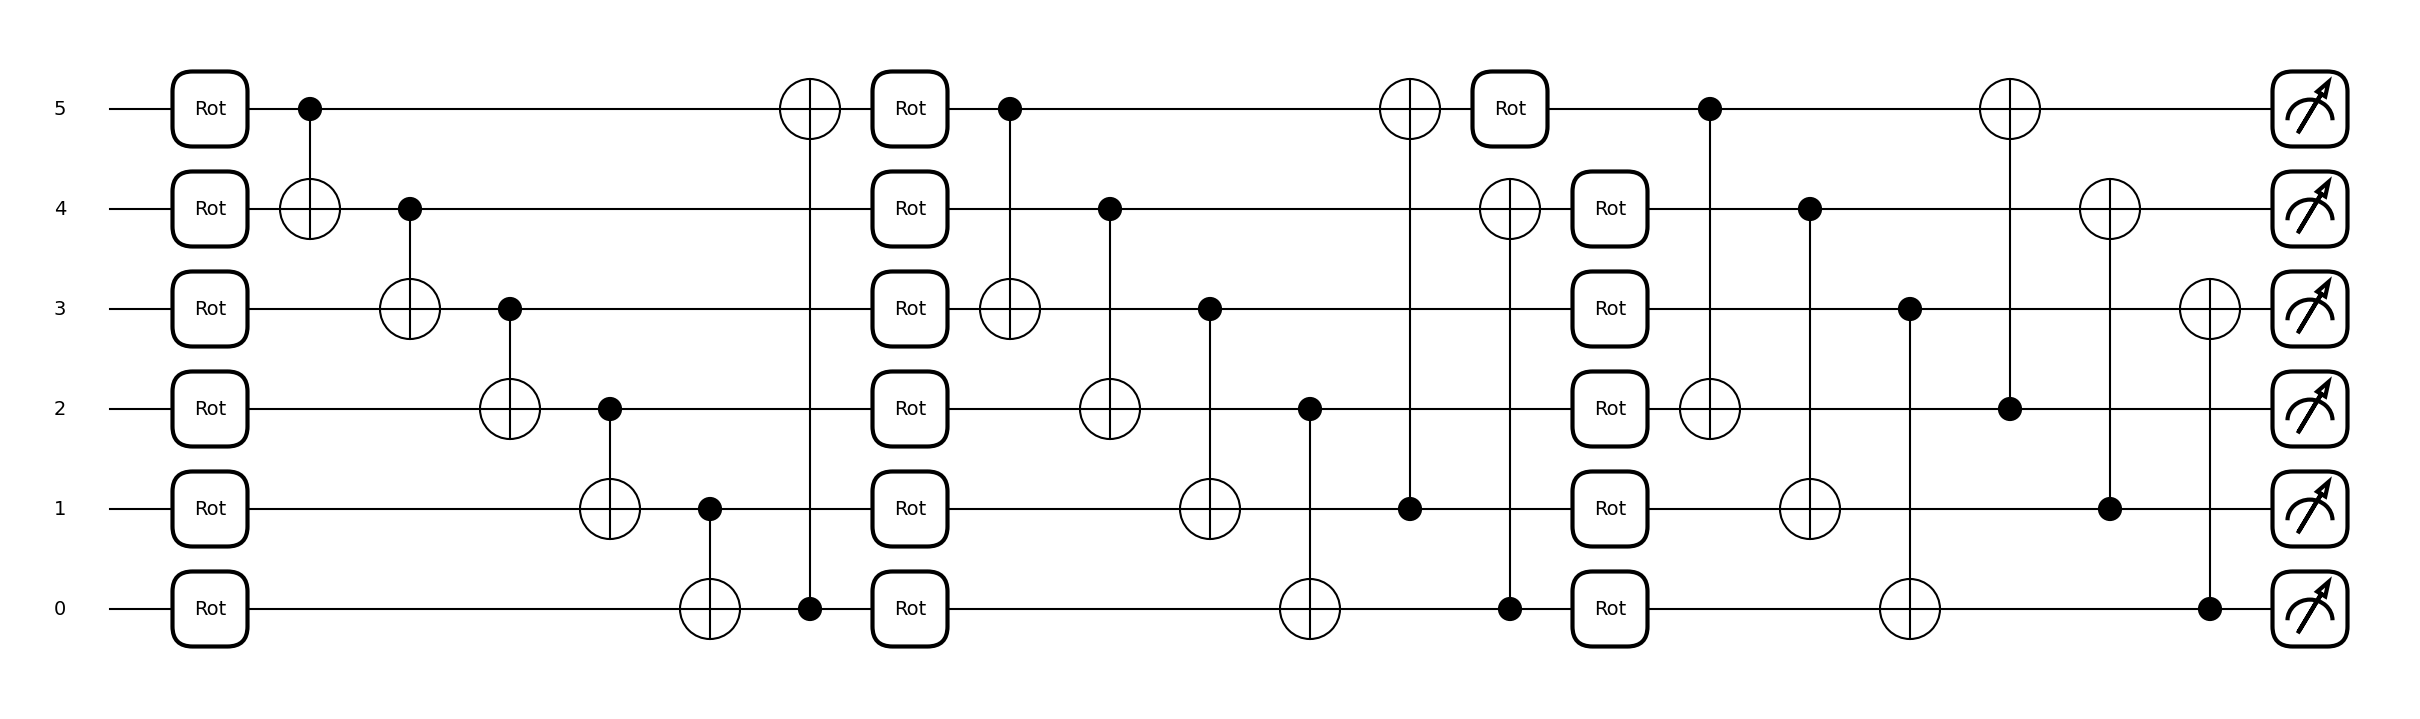

In [23]:
fig, ax = qml.draw_mpl(guassian_qcbm.prob_net)(guassian_qcbm.weights)
fig.show()

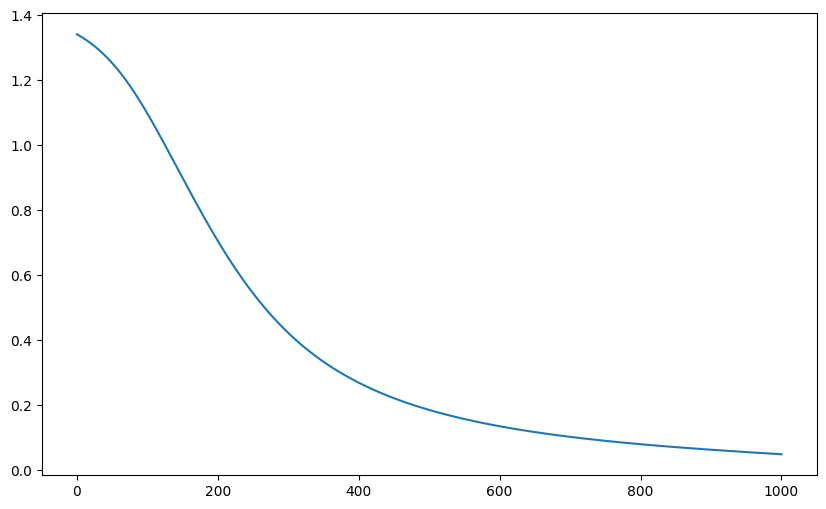

In [12]:
plt.figure(figsize=(10,6))
plt.plot(loss_history)
plt.show()

In [13]:
def plot_probs_vs_target(q_probs, target_probs, centers):
    plt.figure(figsize=(8, 4))
    plt.plot(centers, target_probs.cpu(), label="target", lw=2)
    plt.plot(centers, q_probs.cpu(), label="model", lw=2)
    plt.xlabel("x")
    plt.ylabel("probability density (per bin)")
    plt.legend()
    plt.tight_layout()
    plt.show()

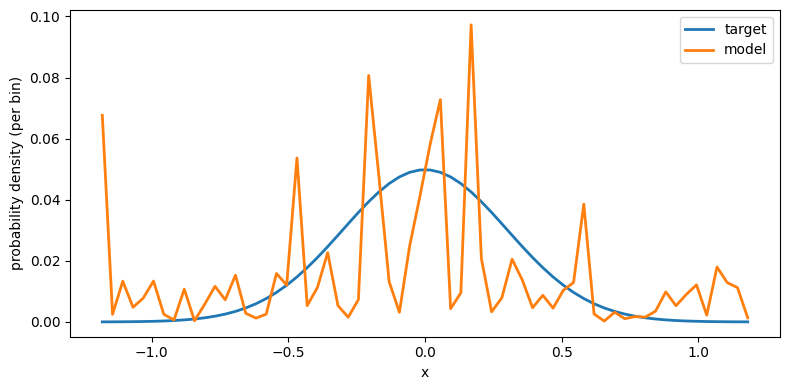

In [14]:
with torch.no_grad():
    q = guassian_qcbm.prob_net(guassian_qcbm.weights)
plot_probs_vs_target(q, probability_distribution, bin_centers)

In [15]:
with torch.no_grad():
    q = guassian_qcbm.prob_net(guassian_qcbm.weights)
    imax = torch.argmax(q).item()
    print("argmax index:", imax, "x at argmax:", bin_centers[imax].item())

argmax index: 36 x at argmax: 0.16875004768371582
